# Data Preparation
The main objective of this notebook is to prepare the Paddy Disease Classification dataset for training a PyTorch image-classification model. The main steps are:

- Define the dataset paths.
- Create training and validation datasets.
- Choose appropriate image transformations.
- Create PyTorch `DataLoader`s.
- Inspect the resulting batches.

By the end of this notebook, we will have:

- A clearly defined training and validation dataset.
- An appropriate preprocessing and augmentation pipeline based on the
  observations from `00_data_observation.ipynb`.
- Images converted into tensors of a consistent size and format.
- Training and validation `DataLoader`s ready to supply batches to a model.
- A clear understanding of the shape, labels, and values of the tensors
  produced by the pipeline.

The final output of this notebook will be a working PyTorch input pipeline:

    Raw images
        ↓
    Dataset
        ↓
    Transformations
        ↓
    Tensor images + labels
        ↓
    DataLoader
        ↓
    Batches ready for training

## 1. Import and Project Setup

### 1. Import Libraries

In [1]:
from pathlib import Path
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split

### 1.2: Define Project Path

In [2]:
PROJECT_ROOT = Path("..")

DATA_DIR = PROJECT_ROOT / "data" / "raw"
TRAIN_DIR = DATA_DIR / "train_images"
TEST_DIR = DATA_DIR / "test_images"

print(f"Training directory: {TRAIN_DIR}")
print(f"Test directory: {TEST_DIR}")

print(f"Training directory exists: {TRAIN_DIR.exists()}")
print(f"Test directory exists: {TEST_DIR.exists()}")

Training directory: ../data/raw/train_images
Test directory: ../data/raw/test_images
Training directory exists: True
Test directory exists: True


## 2. Inspect the Dataset Structure
The training images are organized into one directory per disease class. This structure is directly compatible with `torchvision.datasets.ImageFolder`, which assigns a numerical label to each class.

In [3]:
train_dataset_full = datasets.ImageFolder(TRAIN_DIR)

print(f"Number of images: {len(train_dataset_full)}")
print(f"Number of classes: {len(train_dataset_full.classes)}")
print(f"Classes: {train_dataset_full.classes}")
print(f"Class-to-index mapping: {train_dataset_full.class_to_idx}")

Number of images: 10407
Number of classes: 10
Classes: ['bacterial_leaf_blight', 'bacterial_leaf_streak', 'bacterial_panicle_blight', 'blast', 'brown_spot', 'dead_heart', 'downy_mildew', 'hispa', 'normal', 'tungro']
Class-to-index mapping: {'bacterial_leaf_blight': 0, 'bacterial_leaf_streak': 1, 'bacterial_panicle_blight': 2, 'blast': 3, 'brown_spot': 4, 'dead_heart': 5, 'downy_mildew': 6, 'hispa': 7, 'normal': 8, 'tungro': 9}


## 3. Create the Training and Validation Split
The dataset is class-imbalanced, so we will use a stratified 80/20 split.
A stratified split preserves approximately the same proportion of each disease
class in both the training and validation sets.
A fixed random seed is used to make the split reproducible.

In [4]:
train_size_ratio = 0.8
generator = torch.Generator().manual_seed(42)

targets = torch.tensor(train_dataset_full.targets)

train_indices = []
val_indices = []

for class_idx in range(len(train_dataset_full.classes)):
    class_indices = torch.where(targets == class_idx)[0]

    permutation = torch.randperm(
        len(class_indices),
        generator=generator
    )

    class_indices = class_indices[permutation]

    train_count = round(train_size_ratio * len(class_indices))

    train_indices.extend(class_indices[:train_count].tolist())
    val_indices.extend(class_indices[train_count:].tolist())

train_dataset = torch.utils.data.Subset(
    train_dataset_full,
    train_indices
)

val_dataset = torch.utils.data.Subset(
    train_dataset_full,
    val_indices
)

print(f"Training samples: {len(train_dataset)}")
print(f"Validation samples: {len(val_dataset)}")

Training samples: 8325
Validation samples: 2082


## 4. Select the Pretrained Model and Its Input Preprocessing
We will use EfficientNetV2-S with pretrained ImageNet weights. Rather than manually specifying the preprocessing required by the pretrained model, we will obtain it directly from the corresponding TorchVision weight object. This ensures that the input preprocessing is consistent with the pretrained weights.

In [5]:
# import the pretrained model and it's weights
from torchvision.models import efficientnet_v2_s, EfficientNet_V2_S_Weights

# rename weights
weights = EfficientNet_V2_S_Weights.DEFAULT

# print weights
print(weights)

EfficientNet_V2_S_Weights.IMAGENET1K_V1


In [6]:
weights_transforms = weights.transforms()

print(weights_transforms)

ImageClassification(
    crop_size=[384]
    resize_size=[384]
    mean=[0.485, 0.456, 0.406]
    std=[0.229, 0.224, 0.225]
    interpolation=InterpolationMode.BILINEAR
)


## 5. Define Image Transformations
The transformations are designed around the preprocessing expected by the EfficientNetV2-S ImageNet pretrained weights. Training data will receive limited augmentation intended to introduce realistic variation while preserving disease-related visual features. Validation data will receive deterministic preprocessing only.

### 5.1: ImageNet Normalization
Define the mean and std to be the one obtained from the previous cell:

In [7]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]
print(f"Mean: {IMAGENET_MEAN}")
print(f"Std:  {IMAGENET_STD}")

Mean: [0.485, 0.456, 0.406]
Std:  [0.229, 0.224, 0.225]


### 5.2: Validation Transformation
Validation images will undergo deterministic preprocessing. We resize the images to the size expected by the EfficientNetV2-S pretrained weights, center-crop them, convert them to tensors, and apply ImageNet
normalization.

In [8]:
val_transform = transforms.Compose([
    transforms.Resize(384),
    transforms.CenterCrop(384),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=IMAGENET_MEAN,
        std=IMAGENET_STD
    )
])

In [9]:
print(val_transform)

Compose(
    Resize(size=384, interpolation=bilinear, max_size=None, antialias=True)
    CenterCrop(size=(384, 384))
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)


### 5.3 Training Transformation

The training pipeline includes limited augmentation.

`RandomResizedCrop` introduces variation in scale and spatial framing while
retaining at least 80% of the original image area.

`RandomHorizontalFlip` introduces orientation variation that is unlikely to
change the disease class.

We deliberately avoid strong color augmentation and vertical flipping in the
initial experiment because these transformations may alter or obscure
disease-relevant visual features.

In [10]:
train_transform = transforms.Compose([
    transforms.RandomResizedCrop(384, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=IMAGENET_MEAN,
        std=IMAGENET_STD
    )
])

In [11]:
print(train_transform)

Compose(
    RandomResizedCrop(size=(384, 384), scale=(0.8, 1.0), ratio=(0.75, 1.3333), interpolation=bilinear, antialias=True)
    RandomHorizontalFlip(p=0.5)
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)


## 6. Create Transformed Training and Validation Datasets

The training and validation subsets were already determined using a fixed random
split.

We now create two `ImageFolder` datasets with different transformations and
apply the same subset indices to each one.

This ensures that:

- training images receive random augmentation;
- validation images receive deterministic preprocessing;
- the two subsets contain exactly the same images as determined by the original
  split.

In [12]:
train_dataset_full_transformed = datasets.ImageFolder(
    TRAIN_DIR,
    transform=train_transform
)

val_dataset_full_transformed = datasets.ImageFolder(
    TRAIN_DIR,
    transform=val_transform
)

In [13]:
train_dataset = torch.utils.data.Subset(
    train_dataset_full_transformed,
    train_dataset.indices
)

val_dataset = torch.utils.data.Subset(
    val_dataset_full_transformed,
    val_dataset.indices
)

print(f"Training samples: {len(train_dataset)}")
print(f"Validation samples: {len(val_dataset)}")

Training samples: 8325
Validation samples: 2082


### 6.1: Inspect Transformed Samples

We will inspect transformed training and validation samples to verify that the
preprocessing and augmentation preserve the visual information needed for
disease classification.

In [14]:
train_image, train_label = train_dataset[0]
val_image, val_label = val_dataset[0]

print(f"Training image shape: {train_image.shape}")
print(f"Training image dtype: {train_image.dtype}")
print(f"Training image range: [{train_image.min():.3f}, {train_image.max():.3f}]")
print(f"Training label: {train_label}")

print()

print(f"Validation image shape: {val_image.shape}")
print(f"Validation image dtype: {val_image.dtype}")
print(f"Validation image range: [{val_image.min():.3f}, {val_image.max():.3f}]")
print(f"Validation label: {val_label}")

Training image shape: torch.Size([3, 384, 384])
Training image dtype: torch.float32
Training image range: [-2.067, 2.429]
Training label: 0

Validation image shape: torch.Size([3, 384, 384])
Validation image dtype: torch.float32
Validation image range: [-2.067, 2.429]
Validation label: 0


Let's also visually inspect transformed samples:

In [15]:
def denormalize(image):
    mean = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
    std = torch.tensor(IMAGENET_STD).view(3, 1, 1)
    
    image = image * std + mean
    return image.clamp(0, 1)

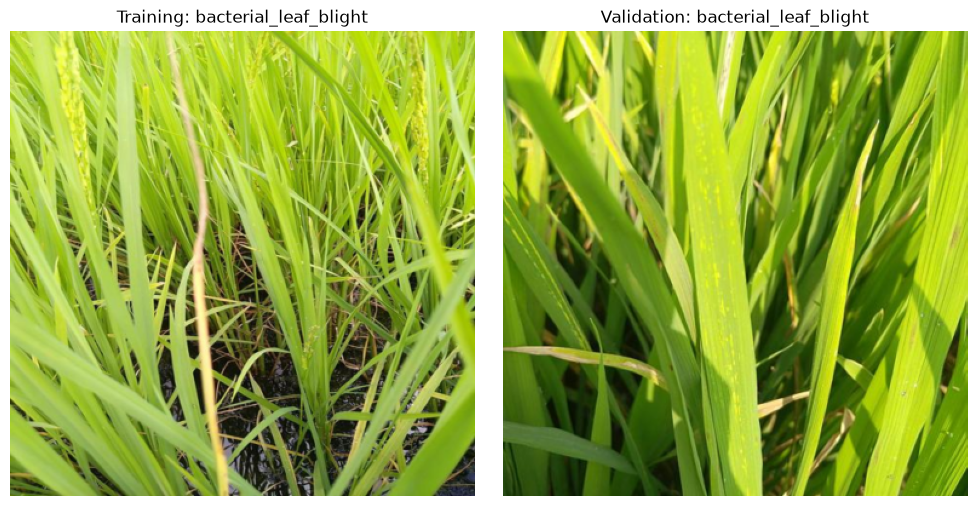

In [16]:
import matplotlib.pyplot as plt

train_image_display = denormalize(train_image)
val_image_display = denormalize(val_image)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

axes[0].imshow(train_image_display.permute(1, 2, 0))
axes[0].set_title(
    f"Training: {train_dataset_full_transformed.classes[train_label]}"
)
axes[0].axis("off")

axes[1].imshow(val_image_display.permute(1, 2, 0))
axes[1].set_title(
    f"Validation: {val_dataset_full_transformed.classes[val_label]}"
)
axes[1].axis("off")

plt.tight_layout()
plt.show()

**Observation:** The transformed training sample retains the relevant leaf
structure and does not appear to remove the disease-related visual context.
Therefore, the chosen augmentation is retained as the baseline training
pipeline.

## 7. Create DataLoaders

DataLoaders provide batches of transformed images and labels to the model during
training and validation.

### 7.1 Define DataLoader Parameters

We will begin with a batch size of 32. The training loader will shuffle the training data, while the validation loader will preserve a deterministic ordering.

In [17]:
BATCH_SIZE = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

print(f"Batch size: {BATCH_SIZE}")
print(f"Training batches: {len(train_loader)}")
print(f"Validation batches: {len(val_loader)}")

Batch size: 32
Training batches: 261
Validation batches: 66


### 7.2 Inspect a Batch
We will inspect one batch to verify the image tensor shape, label tensor shape,
data type, and label values before training the model.

In [18]:
images, labels = next(iter(train_loader))

print(f"Image batch shape: {images.shape}")
print(f"Label batch shape: {labels.shape}")
print(f"Image dtype: {images.dtype}")
print(f"Label dtype: {labels.dtype}")
print(f"Image range: [{images.min():.3f}, {images.max():.3f}]")
print(f"Labels: {labels}")

Image batch shape: torch.Size([32, 3, 384, 384])
Label batch shape: torch.Size([32])
Image dtype: torch.float32
Label dtype: torch.int64
Image range: [-2.118, 2.640]
Labels: tensor([5, 7, 3, 5, 3, 7, 0, 0, 4, 8, 8, 9, 5, 4, 7, 3, 3, 0, 5, 8, 5, 9, 1, 8,
        7, 8, 6, 7, 3, 3, 4, 6])


### 7.3 Check Class Distribution After the Split
The original dataset is class-imbalanced. We therefore verify that the
stratified 80/20 split preserves the class proportions in the training and
validation subsets.

In [19]:
from collections import Counter

class_names = train_dataset_full_transformed.classes

train_labels = [
    train_dataset_full_transformed.targets[i]
    for i in train_dataset.indices
]

val_labels = [
    val_dataset_full_transformed.targets[i]
    for i in val_dataset.indices
]

train_counts = Counter(train_labels)
val_counts = Counter(val_labels)

print("Class distribution:")
print()

for class_idx, class_name in enumerate(class_names):
    print(
        f"{class_name:30s} "
        f"train={train_counts[class_idx]:4d} "
        f"val={val_counts[class_idx]:4d}"
    )

Class distribution:

bacterial_leaf_blight          train= 383 val=  96
bacterial_leaf_streak          train= 304 val=  76
bacterial_panicle_blight       train= 270 val=  67
blast                          train=1390 val= 348
brown_spot                     train= 772 val= 193
dead_heart                     train=1154 val= 288
downy_mildew                   train= 496 val= 124
hispa                          train=1275 val= 319
normal                         train=1411 val= 353
tungro                         train= 870 val= 218
